## Import libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt

## Load data 

In [2]:
df = pd.read_csv("../data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


## Convert the YEAR to datetime and add a Country column

In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["Date"].dt.month

df["Country"] = "Kenya"

# check the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,2015-01-01,1,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,2015-01-02,1,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,2015-01-03,1,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,2015-01-04,1,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,2015-01-05,1,Kenya


## Summary Statistics & Missing-Value Report

In [4]:
# Replace all occurrences of -999 with np.nan
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

# Summary statistics
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


### Interpretation

**Time period:** 4,108 days (~11.25 years), covering 2015 to mid-2026. Day-of-year values (1–366) confirm leap years are included.

**Temperature (°C):**  
Mean temperature is 20.4°C (min 15.3°C, max 25.4°C), with no freezing. Average maximum is 27.8°C (peak 34.3°C), and average minimum is 14.7°C (lowest 9.0°C). The mean diurnal range is 13.2°C, suggesting a subtropical or semi-arid inland setting.

**Precipitation (mm/day):**  
Average is 1.47 mm/day (~536 mm/year). The median is much lower (0.38 mm/day), and the 75th percentile is 1.36 mm/day, indicating most days are dry. The max (51.65 mm/day) shows rare but heavy rain. Distribution is strongly right-skewed.

**Humidity & moisture:**  
Mean relative humidity is 65.8% (range 28.4–91.1%). Mean specific humidity is 11.05 g/kg (4.78–15.04 g/kg), pointing to moderately moist air with some moisture source.

**Wind speed (m/s):**  
Average wind speed is 3.06 m/s (75th percentile 3.72 m/s, max 5.28 m/s). Mean maximum gust is 4.38 m/s (peak 7.59 m/s). Conditions are breezy but not extreme.

**Pressure (kPa):**  
Mean pressure is 83.72 kPa (range 83.31–84.17 kPa), well below sea-level standard (~101.3 kPa). This implies an elevation of roughly 1,450–1,650 meters.

**Overall climate:** Warm temperate / subtropical highland with mild nights, no frost, moderate humidity, mostly dry conditions, and occasional heavy rain. Large diurnal temperature range (~13°C) and elevated terrain.

## Percentage of missing values per column

In [5]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


> No missing values 

## Outlier Detection & Basic Cleaning

In [6]:
# Select numeric columns for outlier detection
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Compute Z-scores (ignoring NaN values)
z_vals = zscore(df[numeric_cols], nan_policy='omit')

# Create a boolean mask for outliers (|Z| > 3)
outlier_mask = (z_vals > 3) | (z_vals < -3)

# Count outliers per column
for i, col in enumerate(numeric_cols):
    col_outlier_count = outlier_mask[:, i].sum()
    print(f"{col}: {col_outlier_count} outliers")

# Flag rows containing any outlier
df["outlier_flag"] = outlier_mask.any(axis=1)
total_outlier_rows = df["outlier_flag"].sum()
print(f"\nTotal rows with at least one outlier: {total_outlier_rows}")

T2M: 8 outliers
T2M_MAX: 3 outliers
T2M_MIN: 9 outliers
PRECTOTCORR: 92 outliers
RH2M: 6 outliers
WS2M: 0 outliers
WS2M_MAX: 6 outliers

Total rows with at least one outlier: 121


**Outlier handling decision:**
For temperature variables (T2M, T2M_MAX, T2M_MIN) and RH2M, I will retain outliers because these values are climatically possible (e.g., natural heatwaves or dry days). For WS2M and WS2M_MAX, I will also retain them as wind gusts can be legitimate. For PRECTOTCORR, extreme values (|Z|>3) likely represent real heavy rainfall events, so I will retain all outliers. No capping or dropping is necessary unless further analysis requires normality.

## Export the cleaned DataFrame

In [7]:
df.to_csv(f"../data/kenya_clean.csv", index=False)

## Time Series Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_7052\1100436767.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('Date').resample('M')['T2M'].mean().reset_index()


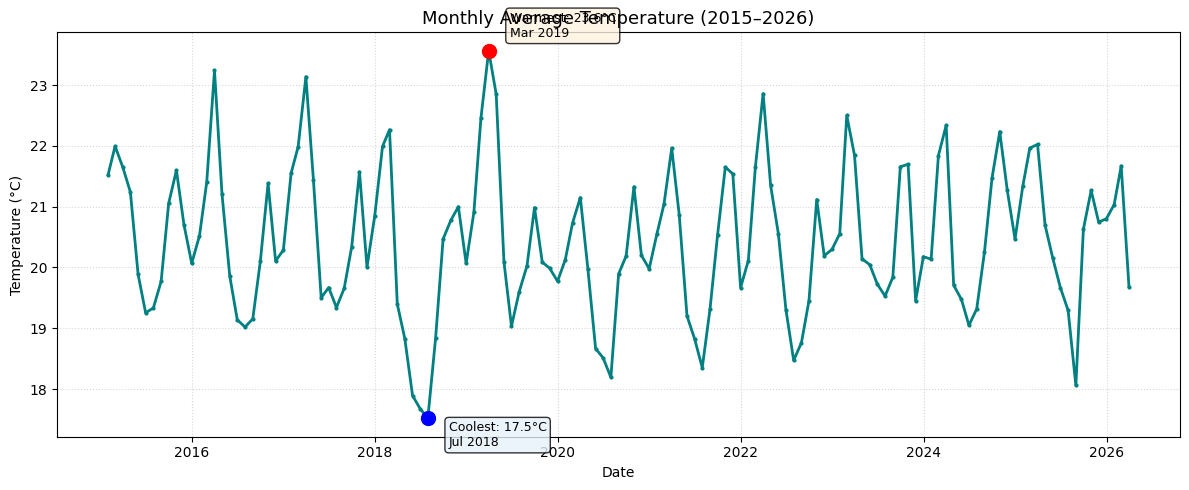

In [7]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create monthly averages
df_monthly = df.set_index('Date').resample('M')['T2M'].mean().reset_index()

# Identify warmest and coolest months
warmest = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest = df_monthly.loc[df_monthly['T2M'].idxmin()]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_monthly['Date'], df_monthly['T2M'], color='teal', linewidth=2, marker='.', markersize=4)

# Annotate warmest month
ax.plot(warmest['Date'], warmest['T2M'], 'ro', markersize=10)
ax.annotate(f"Warmest: {warmest['T2M']:.1f}°C\n{warmest['Date'].strftime('%b %Y')}",
            xy=(warmest['Date'], warmest['T2M']), xytext=(15, 10),
            textcoords='offset points', fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', alpha=0.8))

# Annotate coolest month
ax.plot(coolest['Date'], coolest['T2M'], 'bo', markersize=10)
ax.annotate(f"Coolest: {coolest['T2M']:.1f}°C\n{coolest['Date'].strftime('%b %Y')}",
            xy=(coolest['Date'], coolest['T2M']), xytext=(15, -20),
            textcoords='offset points', fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e6f0fa', alpha=0.8))

# Labels and title
ax.set_title('Monthly Average Temperature (2015–2026)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Monthly average **T2M** (2015–2026)

**What the chart shows:**  
The line plot reveals a clear seasonal pattern in temperature. Variations align closely with the time of year rather than showing a long-term warming or cooling trend across the 12-year period.
 
Two points are highlighted: the month with the highest average T2M and the month with the lowest average T2M over the entire dataset. These correspond to the peak of the warm season and the peak of the cool season, respectively, for this location between 2015 and 2026.

C:\Users\hp\AppData\Local\Temp\ipykernel_7052\3852893881.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df.resample('M', on='Date')['PRECTOTCORR'].sum().reset_index()


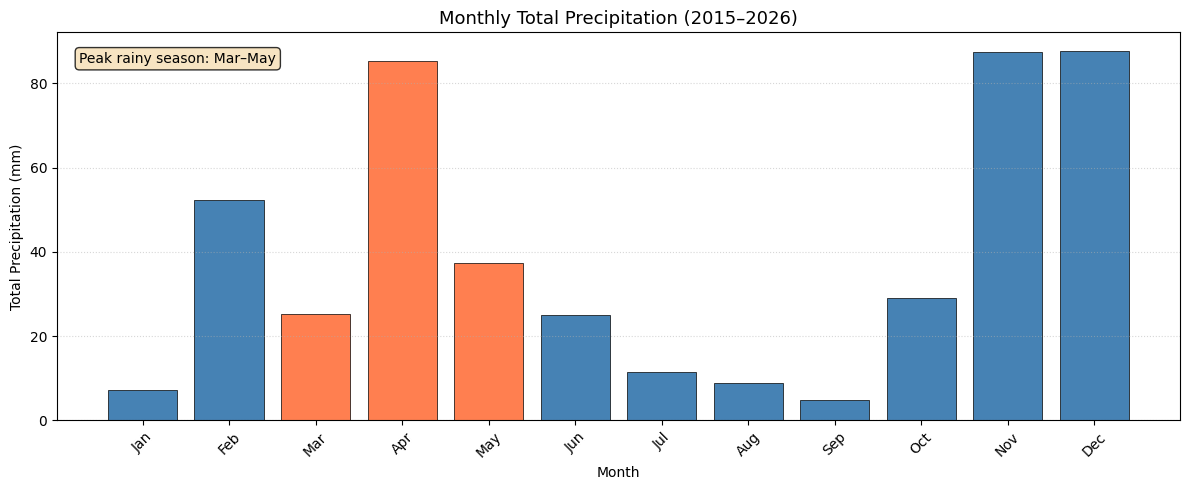

In [ ]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Calculate monthly total precipitation
monthly_rain = df.resample('M', on='Date')['PRECTOTCORR'].sum().reset_index()
monthly_rain['Month'] = monthly_rain['Date'].dt.month
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Find peak rainy season (3 consecutive months with highest total)
monthly_sums = monthly_rain.groupby('Month')['PRECTOTCORR'].sum()

best_total = 0
peak_months = [12, 1, 2]  # default

for start in range(1, 13):
    # Build 3-month window with wrapping (1-12 only)
    three_months = []
    for offset in range(3):
        m = start + offset
        if m > 12:
            m = m - 12
        three_months.append(m)
    
    total = sum(monthly_sums[m] for m in three_months)
    if total > best_total:
        best_total = total
        peak_months = three_months

# Create color mapping: highlight peak season months
monthly_rain['color'] = monthly_rain['Month'].apply(
    lambda m: 'coral' if m in peak_months else 'steelblue'
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

for month_name in monthly_rain['Month_Name'].unique():
    subset = monthly_rain[monthly_rain['Month_Name'] == month_name]
    color = subset['color'].iloc[0]
    ax.bar(month_name, subset['PRECTOTCORR'].iloc[0], color=color, edgecolor='black', linewidth=0.5)

# Annotate peak season
peak_month_names = [monthly_rain[monthly_rain['Month'] == m]['Month_Name'].iloc[0] for m in peak_months]

if peak_months[0] > peak_months[1]:  # wrapped case (e.g., Dec, Jan, Feb)
    peak_label = f"Peak rainy season: {', '.join(peak_month_names)}"
else:
    peak_label = f"Peak rainy season: {peak_month_names[0]}–{peak_month_names[-1]}"

ax.text(0.02, 0.95, peak_label, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title('Monthly Total Precipitation (2015–2026)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Total Precipitation (mm)')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly total **PRECTOTCORR**

**What the chart shows:**  
Rainfall is unevenly distributed across the year, with a clear seasonal pattern. A small number of months receive the vast majority of precipitation, while many months are relatively dry.
- The three months with the highest total rainfall are labeled directly on the bar chart.
- These represent the most likely periods for peak rainy season activity within this dataset.

## Correlation & Relationship Analysis

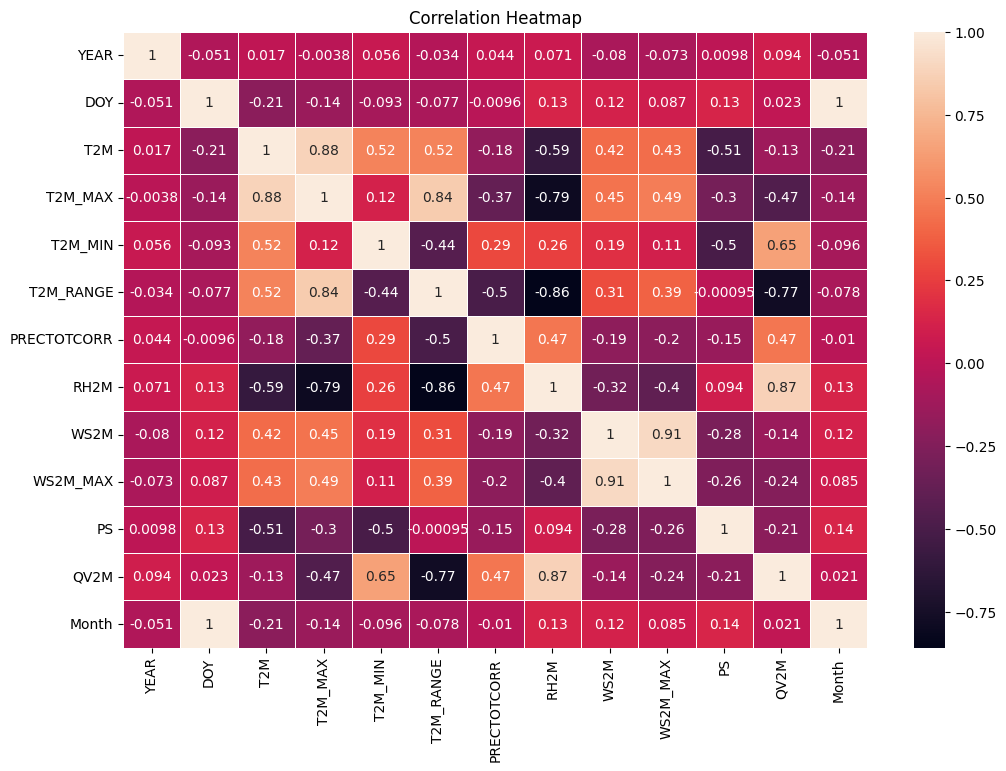

In [13]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

#### 1. WS2M` and WS2M_MAX: correlation ≈ **0.91**  
    when the *average* wind speed is higher, the *maximum* wind speed that day is also higher—very consistent relationship.

#### 3. T2M and T2M_MAX: correlation ≈ **0.88**  
    Warmer days on average also have higher daytime peaks, which is exactly what we’d expect.

#### 4. RH2M and QV2M: correlation ≈ **0.87**  
    Relative humidity and specific humidity rise together most of the time; they’re different ways of describing atmospheric moisture, so strong coupling makes sense.

### Scatter Plots

### T2M vs RH2M 

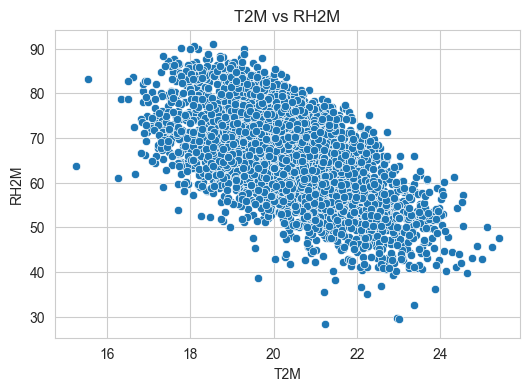

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### **T2M vs RH2M**

The plot shows a dispersed cluster rather than a tight linear relationship. This indicates that while temperature plays a role in shaping humidity, other factors — such as rainfall, seasonal shifts, and local weather patterns — also contribute significantly. A slight downward slope is visible across the cloud of points. This suggests that higher temperatures are generally associated with lower relative humidity, a pattern observed in many climate regimes worldwide.


### T2M_RANGE vs WS2M

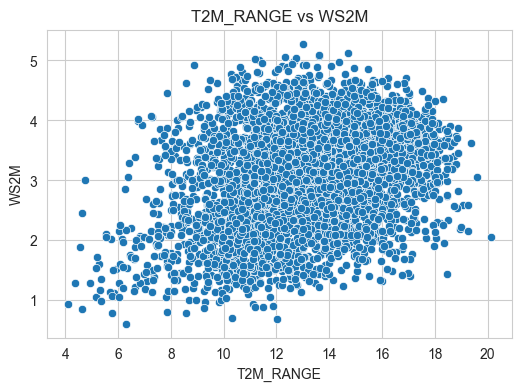

In [33]:
### Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

### **T2M_RANGE vs WS2M**

This plot explores whether larger diurnal temperature swings occur on windier days.

A weak upward slope is visible, suggesting that higher wind speeds tend to accompany a wider temperature range. However, the points form a loose, blob-like shape rather than a tight pattern. This indicates that wind speed is not a dominant or consistent driver of daily temperature range in this dataset.

## Distribution Analysis

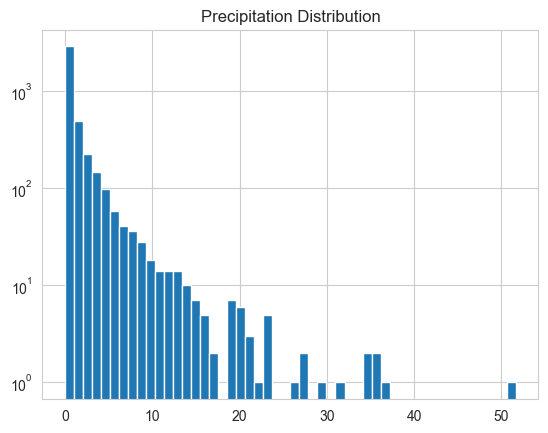

In [ ]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.yscale("log") 
plt.title("Precipitation Histogram")
plt.show()

### Histogram **PRECTOTCORR** 

- The vast majority of days record **little to no rainfall**, clustering at the lower end of the distribution.
- A much smaller subset of days shows **high rainfall amounts**, representing storm events that create a long tail stretching to the right.


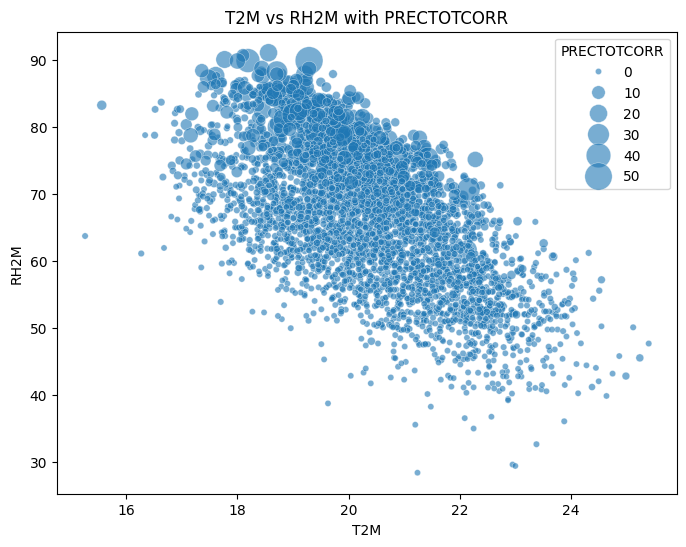

In [14]:
## bubble chart
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 400),
    alpha=0.6,
    legend=True
)

plt.title("T2M vs RH2M with PRECTOTCORR")
plt.show()

### **T2M vs RH2M**, bubble size = **PRECTOTCORR**

This visualization combines temperature, humidity, and rainfall intensity into a single plot. The largest bubbles (indicating high precipitation) are clustered in the **upper-left area** of the chart. Those big bubbles occur at **elevated RH2M levels** (more humid air) alongside **moderate temperatures**, confirming that rain events are strongly associated with moist atmospheric conditions.